In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

csv_path = "patient_diagnosis.csv"

# Load CSV
patient_diagnosis = pd.read_csv('patient_diagnosis.csv', names=['Patient Number', 'Diagnosis'])
patient_diagnosis


,Patient Number,Diagnosis
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI
...,...,...
121,222,COPD
122,223,COPD
123,224,Healthy
124,225,Healthy


In [2]:
categories = patient_diagnosis['Diagnosis'].unique()
categories

array(['URTI', 'Healthy', 'Asthma', 'COPD', 'LRTI', 'Bronchiectasis',
       'Pneumonia', 'Bronchiolitis'], dtype=object)

In [3]:
demographic_info = pd.read_csv('demographic_info.txt', names=[
    'Patient Number', 'Age', 'Sex', 'Adult BMI (kg/m2)', 'Child Weight (kg)', 'Child Height (cm)'], delimiter=' ')

demographic_info

,Patient Number,Age,Sex,Adult BMI (kg/m2),Child Weight (kg),Child Height (cm)
0,101,3.00,F,NaN,19.0,99.0
1,102,0.75,F,NaN,9.8,73.0
2,103,70.00,F,33.00,NaN,NaN
3,104,70.00,F,28.47,NaN,NaN
4,105,7.00,F,NaN,32.0,135.0
...,...,...,...,...,...,...
121,222,60.00,M,NaN,NaN,NaN
122,223,NaN,NaN,NaN,NaN,NaN
123,224,10.00,F,NaN,32.3,143.0
124,225,0.83,M,NaN,7.8,74.0


In [4]:
def clean_metadata(metadata_path):
  df = pd.read_csv(metadata_path, sep=" ", header=None, names=[ 'Patient Number', 'Age', 'Sex', 'Adult BMI (kg/m2)', 'Child Weight (kg)', 'Child Height (cm)'])
  #considering child under 18
  mask_kids = df["Age"] < 18
  df.loc[mask_kids, "Child BMI (kg/m2)"] = df.loc[mask_kids].apply(
      lambda row: row["Child Weight (kg)"] / ((row["Child Height (cm)"] / 100) ** 2)
      if not pd.isnull(row["Child Weight (kg)"]) and not pd.isnull(row["Child Height (cm)"]) else np.nan,
      axis=1,
  )
  # merge bmi and drop useless
  df["BMI (kg/m2)"] = df["Adult BMI (kg/m2)"].fillna(df["Child BMI (kg/m2)"])
  df.drop(["Child BMI (kg/m2)", "Child Height (cm)", "Child Weight (kg)", "Adult BMI (kg/m2)"], axis=1, inplace=True)
  # Add column for sound path
  return df

clean_demographic_info=clean_metadata('demographic_info.txt')
clean_demographic_info

,Patient Number,Age,Sex,BMI (kg/m2)
0,101,3.00,F,19.385777
1,102,0.75,F,18.389942
2,103,70.00,F,33.000000
3,104,70.00,F,28.470000
4,105,7.00,F,17.558299
...,...,...,...,...
121,222,60.00,M,NaN
122,223,NaN,NaN,NaN
123,224,10.00,F,15.795393
124,225,0.83,M,14.243974


In [5]:
merged_df = pd.merge(clean_demographic_info, patient_diagnosis, on='Patient Number', how='inner')
merged_df

,Patient Number,Age,Sex,BMI (kg/m2),Diagnosis
0,101,3.00,F,19.385777,URTI
1,102,0.75,F,18.389942,Healthy
2,103,70.00,F,33.000000,Asthma
3,104,70.00,F,28.470000,COPD
4,105,7.00,F,17.558299,URTI
...,...,...,...,...,...
121,222,60.00,M,NaN,COPD
122,223,NaN,NaN,NaN,COPD
123,224,10.00,F,15.795393,Healthy
124,225,0.83,M,14.243974,Healthy


**Patient number** (101,102,...,226) <br>
**Recording index** <br>
**Chest location** (Trachea (Tc), {Anterior (A), Posterior (P), Lateral (L)}{left (l), right (r)}) <br>
**Acquisition mode** (sequential/single channel (sc), simultaneous/multichannel (mc)) <br>
**Recording equipment** (AKG C417L Microphone, 3M Littmann Classic II SE Stethoscope, 3M Litmmann 3200 Electronic Stethoscope, WelchAllyn Meditron Master Elite Electronic Stethoscope)

In [13]:
import os
import glob
# Now preprocessing Audio_and_Text files
# Extraction info from file names

audio_path = 'audio_and_txt_files/'

# adding columns 
file_names = []
patient_number = []
recording_index = []
chest_location = []
acquisition_mode = []
recording_equipment = []


for path in glob.glob(os.path.join(audio_path, "*.wav")):
    file = os.path.basename(path).replace(".wav", "")
    parts = file.split("_")

    if len(parts) >= 5:
        # Extract components
        file_names.append(file)
        patient_number.append(parts[0])
        recording_index.append(parts[1])
        chest_location.append(parts[2])
        acquisition_mode.append(parts[3])
        recording_equipment.append(parts[4])


# Create DataFrame
df_audio = pd.DataFrame({
    "Filename": file_names,
    "Patient Number": patient_number,
    "Recording Index": recording_index,
    "Chest Location": chest_location,
    "Acquisition Mode": acquisition_mode,
    "Recording Equipment": recording_equipment
})

df_audio

,Filename,Patient Number,Recording Index,Chest Location,Acquisition Mode,Recording Equipment
0,101_1b1_Al_sc_Meditron,101,1b1,Al,sc,Meditron
1,101_1b1_Pr_sc_Meditron,101,1b1,Pr,sc,Meditron
2,102_1b1_Ar_sc_Meditron,102,1b1,Ar,sc,Meditron
3,103_2b2_Ar_mc_LittC2SE,103,2b2,Ar,mc,LittC2SE
4,104_1b1_Al_sc_Litt3200,104,1b1,Al,sc,Litt3200
...,...,...,...,...,...,...
915,224_1b2_Al_sc_Meditron,224,1b2,Al,sc,Meditron
916,225_1b1_Pl_sc_Meditron,225,1b1,Pl,sc,Meditron
917,226_1b1_Al_sc_Meditron,226,1b1,Al,sc,Meditron
918,226_1b1_Ll_sc_Meditron,226,1b1,Ll,sc,Meditron


Audio loaded: (882000,) Sample rate: 44100
Duration: 20.00 seconds


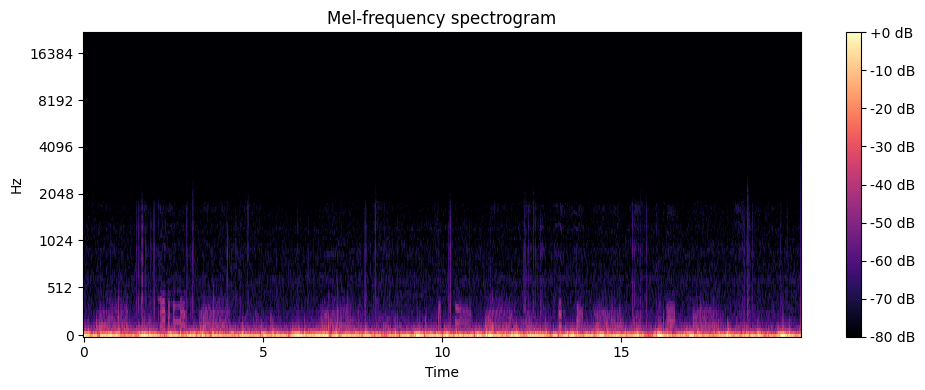

In [20]:
import librosa
import librosa.display
import matplotlib.pyplot as plt


def visualize_mel(input_path):
    # Load audio
    y, sr = librosa.load(input_path, sr=None)  # sr=None keeps original sampling rate
    print('Audio loaded:', y.shape, 'Sample rate:', sr)
    duration = librosa.get_duration(y=y, sr=sr)
    print(f"Duration: {duration:.2f} seconds")

    # Compute mel spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel_spectrogram, ref=np.max)  # convert to dB

    # Plot
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel-frequency spectrogram')
    plt.tight_layout()
    plt.show()

filename = df_audio.iloc[0]['Filename'] + ".wav" #first audio file
path = os.path.join(audio_path, filename)
visualize_mel('audio_and_txt_files/103_2b2_Ar_mc_LittC2SE.wav')


101_1b1_Pr_sc_Meditron.wav
Audio loaded: (882000,) Sample rate: 44100
Duration: 20.00 seconds


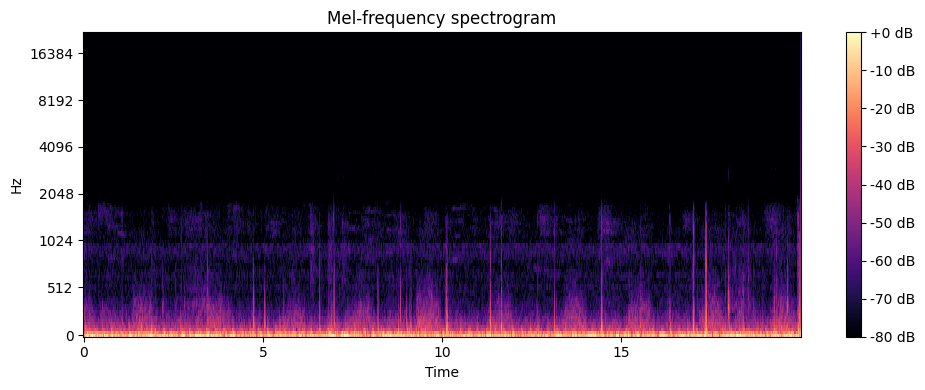

In [83]:
filename = df_audio.iloc[1]['Filename'] + ".wav" #second audio file
path = os.path.join(audio_path, filename)
print(filename)
visualize_mel(path)

Audio loaded: (882000,) Sample rate: 44100
Duration: 20.00 seconds


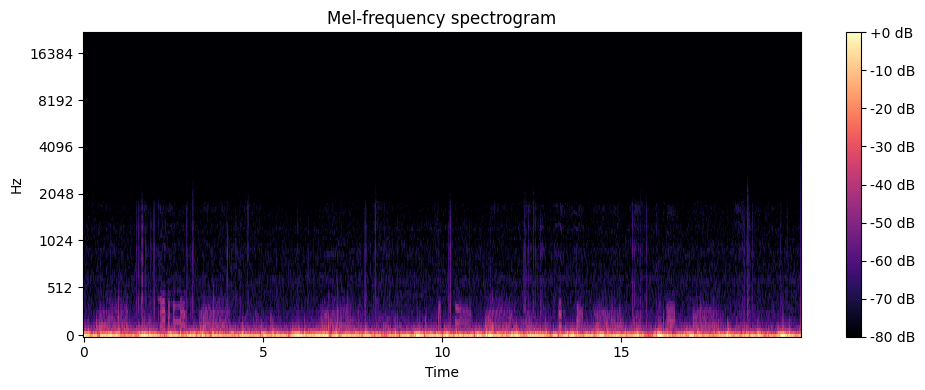

In [84]:
visualize_mel('audio_and_txt_files/103_2b2_Ar_mc_LittC2SE.wav') #specific audio file

In [85]:
audio_annotations = []

# Loop over all .txt files
for txt_file in glob.glob(os.path.join(audio_path, "*.txt")):
    file_name = os.path.basename(txt_file).replace(".txt", "")
    #print(file_name)

    try:
        # Read annotation file
        df = pd.read_csv(txt_file, names=['Start', 'End', 'Crackles', 'Wheezes'], delimiter='\t')
        df["Filename"] = file_name 
        audio_annotations.append(df)
    except Exception as e:
        print(f"Failed to read {txt_file}: {e}")

df_annotations = pd.concat(audio_annotations, ignore_index=True)

df_annotations = df_annotations[["Filename", "Start", "End", "Crackles", "Wheezes"]]

df_annotations

,Filename,Start,End,Crackles,Wheezes
0,101_1b1_Al_sc_Meditron,0.036,0.579,0,0
1,101_1b1_Al_sc_Meditron,0.579,2.450,0,0
2,101_1b1_Al_sc_Meditron,2.450,3.893,0,0
3,101_1b1_Al_sc_Meditron,3.893,5.793,0,0
4,101_1b1_Al_sc_Meditron,5.793,7.521,0,0
...,...,...,...,...,...
6893,226_1b1_Pl_sc_LittC2SE,11.721,13.693,1,0
6894,226_1b1_Pl_sc_LittC2SE,13.693,15.536,0,0
6895,226_1b1_Pl_sc_LittC2SE,15.536,17.493,0,0
6896,226_1b1_Pl_sc_LittC2SE,17.493,19.436,1,0


In [43]:
import soundfile as sf

def seg_and_save(input_path, meta_file, output_dir):
    y, sr = librosa.load(input_path, sr=None)  # sr=None keeps original sampling rate
    print('Audio loaded:', y.shape, 'Sample rate:', sr)

    df = pd.read_csv(meta_file, sep='\t', header=None, names=['Start', 'End', 'Crackle', 'Wheeze'])
    print('Metadata loaded:', df.shape)
    
    os.makedirs(output_dir, exist_ok=True)

    for index, row in df.iterrows():
        label = f"{int(row['Crackle'])}{int(row['Wheeze'])}"
        print(os.path.basename(input_path))
        input_name = os.path.splitext(os.path.basename(input_path))[-3:]
        print(input_name)
        new_name = os.path.basename(input_path).replace('.wav', f'_cycle_{index}_label_{label}.wav')
        out_path = os.path.join(output_dir, new_name)
        start_sample = int(row['Start'] * sr)
        end_sample = int(row['End'] * sr)
        segment = y[start_sample:end_sample]
        sf.write(out_path, segment, sr)
        print(f"Segment saved: {new_name} from {row['Start']} to {row['End']} seconds with label {label}")
    print("All segments saved successfully.")


output_dir='segmented_files'

for i, meta_file in enumerate(glob.glob(os.path.join(audio_path, "*.txt"))):
#    if i >= 5:  
#        break
    input_path = os.path.splitext(meta_file)[0] + ".wav"
    seg_and_save(input_path, meta_file, output_dir)




Audio loaded: (882000,) Sample rate: 44100
Metadata loaded: (12, 4)
101_1b1_Al_sc_Meditron.wav
('101_1b1_Al_sc_Meditron', '.wav')
Segment saved: 101_1b1_Al_sc_Meditron_cycle_0_label_00.wav from 0.036 to 0.579 seconds with label 00
101_1b1_Al_sc_Meditron.wav
('101_1b1_Al_sc_Meditron', '.wav')
Segment saved: 101_1b1_Al_sc_Meditron_cycle_1_label_00.wav from 0.579 to 2.45 seconds with label 00
101_1b1_Al_sc_Meditron.wav
('101_1b1_Al_sc_Meditron', '.wav')
Segment saved: 101_1b1_Al_sc_Meditron_cycle_2_label_00.wav from 2.45 to 3.893 seconds with label 00
101_1b1_Al_sc_Meditron.wav
('101_1b1_Al_sc_Meditron', '.wav')
Segment saved: 101_1b1_Al_sc_Meditron_cycle_3_label_00.wav from 3.893 to 5.793 seconds with label 00
101_1b1_Al_sc_Meditron.wav
('101_1b1_Al_sc_Meditron', '.wav')
Segment saved: 101_1b1_Al_sc_Meditron_cycle_4_label_00.wav from 5.793 to 7.521 seconds with label 00
101_1b1_Al_sc_Meditron.wav
('101_1b1_Al_sc_Meditron', '.wav')
Segment saved: 101_1b1_Al_sc_Meditron_cycle_5_label_00.wa

In [ ]:
nan_counts = merged_df.isna().sum()
print("NaN values per column:")
print(nan_counts)

# Get rows where ANY column has NaN
rows_with_nan = merged_df[merged_df.isna().any(axis=1)]
print("\nRows with missing values:")
print(rows_with_nan)

NaN values per column:
Patient Number    0
Age               0
Sex               0
BMI (kg/m2)       0
Diagnosis         0
dtype: int64

Rows with missing values:
Empty DataFrame
Columns: [Patient Number, Age, Sex, BMI (kg/m2), Diagnosis]
Index: []


,Patient Number,Age,Sex,BMI (kg/m2),Diagnosis
0,101,3.00,F,19.385777,URTI
1,102,0.75,F,18.389942,Healthy
2,103,70.00,F,33.000000,Asthma
3,104,70.00,F,28.470000,COPD
4,105,7.00,F,17.558299,URTI
...,...,...,...,...,...
119,220,66.00,M,35.400000,COPD
120,221,74.00,F,29.000000,COPD
123,224,10.00,F,15.795393,Healthy
124,225,0.83,M,14.243974,Healthy


In [47]:
merged_df = merged_df.dropna()
nan_counts = merged_df.isna().sum()
print("NaN values per column:")
print(nan_counts)

NaN values per column:
Patient Number    0
Age               0
Sex               0
BMI (kg/m2)       0
Diagnosis         0
dtype: int64


In [87]:
# Count diagnosis occurrences in merged_df
diag_counts = merged_df['Diagnosis'].value_counts()
print("Diagnosis counts:")
print(diag_counts)

Diagnosis counts:
Diagnosis
COPD              62
Healthy           24
URTI              11
Bronchiectasis     7
Pneumonia          6
Bronchiolitis      5
Asthma             1
LRTI               1
Name: count, dtype: int64


In [1]:
#Model without group aware data split
# Cell: extract features from segmented wavs, merge with demographics, and train RF
import os, glob, re
import numpy as np
import librosa
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib

seg_dir = 'segmented_files'
feature_rows = []

# ...existing code...
def extract_features_from_audio(path, n_mfcc=13):
    y, sr = librosa.load(path, sr=None)
    if y.size == 0:
        return None

    # MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)

    # spectral features
    centroid = float(librosa.feature.spectral_centroid(y=y, sr=sr).mean())
    bandwidth = float(librosa.feature.spectral_bandwidth(y=y, sr=sr).mean())
    rolloff = float(librosa.feature.spectral_rolloff(y=y, sr=sr).mean())
    zcr = float(librosa.feature.zero_crossing_rate(y).mean())

    # compute RMS from the power spectrogram and pass it with the S= keyword
    S = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))**2
    rms_vals = librosa.feature.rms(S=S)   # avoid positional-arg ambiguity
    rms = float(rms_vals.mean())

    # dominant frequency via FFT peak
    fft = np.abs(np.fft.rfft(y))
    freqs = np.fft.rfftfreq(len(y), 1 / sr) if len(y) > 0 else np.array([0.0])
    dom_freq = float(freqs[np.argmax(fft)]) if fft.size > 0 else 0.0

    feats = {}
    for i, (m, s) in enumerate(zip(mfcc_mean, mfcc_std), start=1):
        feats[f"mfcc{i}_mean"] = float(m)
        feats[f"mfcc{i}_std"] = float(s)
    feats.update({
        "centroid": centroid,
        "bandwidth": bandwidth,
        "rolloff": rolloff,
        "zcr": zcr,
        "rms": rms,
        "dom_freq": dom_freq,
        "sr": int(sr),
    })
    return feats
# ...existing code...

for fp in glob.glob(os.path.join(seg_dir, "*.wav")):
    fname = os.path.basename(fp)
    feats = extract_features_from_audio(fp)
    if feats is None:
        continue
    # get leading patient number (digits) from filename
    m = re.match(r"(\d+)", fname)
    patient_num = m.group(1) if m else ''
    # try to extract segment-level label (if produced by seg_and_save)
    label_search = re.search(r"label_?(\d+)", fname)
    seg_label = label_search.group(1) if label_search else None
    feats.update({"filename": fname, "patient_number": str(patient_num), "segment_label": seg_label})
    feature_rows.append(feats)

df_sound_features = pd.DataFrame(feature_rows)
print("Extracted sound features:", df_sound_features.shape)

# Merge with demographics
df_sound_features['patient_number'] = df_sound_features['patient_number'].astype(str).str.strip()
merged_df['Patient Number'] = merged_df['Patient Number'].astype(str).str.strip()

df_all = df_sound_features.merge(merged_df, left_on='patient_number', right_on='Patient Number', how='left')
df_all = df_all.dropna(subset=['Diagnosis'])  # keep only rows with target
print("After merge:", df_all.shape)

# select features
numeric_sound = [c for c in df_sound_features.columns if c.startswith('mfcc') or c in ('centroid','bandwidth','rolloff','zcr','rms','dom_freq')]
numeric_dem = ['Age', 'BMI (kg/m2)']
cat_dem = ['Sex']

available_num = [c for c in numeric_sound + numeric_dem if c in df_all.columns]
available_cat = [c for c in cat_dem if c in df_all.columns]

X = df_all[available_num + available_cat].copy()
y = df_all['Diagnosis'].copy()

# if stratify fails because of small class counts, fall back to no stratify
stratify = y if y.nunique() > 1 and all(y.value_counts() >= 2) else None

preproc = ColumnTransformer([
    ('num', StandardScaler(), [c for c in available_num]),
    ('cat', OneHotEncoder(handle_unknown='ignore'), available_cat),
], remainder='drop')

clf = Pipeline([
    ('preproc', preproc),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=stratify, random_state=42)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print(classification_report(y_test, pred))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))

joblib.dump(clf, 'rf_sound_demographics_pipeline.joblib')
print("Model saved: rf_sound_demographics_pipeline.joblib")
# ...existing code...

C:\Users\SAVVY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1848
  warnings.warn(


NameError: name 'pd' is not defined

In [88]:
print("Segment-level accuracy before group-aware data split:", accuracy_score(y_test, pred))

Segment-level accuracy before group-aware data split: 0.864406779661017


In [ ]:
# ...existing code...
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score

# ensure patient grouping column exists and is string-typed
groups = df_all['patient_number'].astype(str).values

# group-aware split: all segments for a patient stay together
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# fit pipeline (preproc + rf defined earlier)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print("Segment-level classification report:")
print(classification_report(y_test, pred))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))
print("Segment-level accuracy:", accuracy_score(y_test, pred))

# Patient-level majority vote aggregation on test set
res = pd.DataFrame({
    'patient_number': df_all.loc[X_test.index, 'patient_number'].astype(str).values,
    'y_true': y_test.values,
    'y_pred': pred
})

patient_pred = (
    res.groupby('patient_number')
       .agg(y_true=('y_true', 'first'),
            y_pred=('y_pred', lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]))
       .reset_index()
)

from sklearn.metrics import classification_report as cr
print("\nPatient-level (majority vote) classification report:")
print(cr(patient_pred['y_true'], patient_pred['y_pred']))
from sklearn.metrics import confusion_matrix as cm
print("Patient-level confusion matrix:\n", cm(patient_pred['y_true'], patient_pred['y_pred']))

# save final pipeline trained on training split (optional: train on all patients for final model)
import joblib
joblib.dump(clf, 'rf_sound_demographics_pipeline_group_split.joblib')
print("Model saved: rf_sound_demographics_pipeline_group_split.joblib")
# ...existing code...

Segment-level classification report:
                precision    recall  f1-score   support

Bronchiectasis       0.00      0.00      0.00        41
 Bronchiolitis       0.00      0.00      0.00         0
          COPD       0.93      1.00      0.96       877
       Healthy       0.44      0.61      0.51        66
     Pneumonia       0.67      0.08      0.15        24
          URTI       0.00      0.00      0.00        54

      accuracy                           0.86      1062
     macro avg       0.34      0.28      0.27      1062
  weighted avg       0.81      0.86      0.83      1062

Confusion matrix:
 [[  0   0  41   0   0   0]
 [  0   0   0   0   0   0]
 [  0   0 876   0   1   0]
 [  0  10   0  40   0  16]
 [  0   0  22   0   2   0]
 [  0   3   0  51   0   0]]
Segment-level accuracy: 0.864406779661017

Patient-level (majority vote) classification report:
                precision    recall  f1-score   support

Bronchiectasis       0.00      0.00      0.00         1
 Bronchio

In [86]:
print("Patient-level accuracy:", accuracy_score(patient_pred['y_true'], patient_pred['y_pred']))

Patient-level accuracy: 0.7083333333333334


In [ ]:
# Compute patients for which the model predicted the same label for every segment
# AND that predicted label matched the true label for every segment.
import pandas as pd

if 'res' not in globals():
    res = pd.DataFrame({
        'patient_number': df_all.loc[X_test.index, 'patient_number'].astype(str).values,
        'y_true': y_test.values,
        'y_pred': pred
    })

# per-patient stats
per_patient_stats = (
    res.groupby('patient_number')
       .agg(
           n_segments=('y_pred', 'size'),
           n_unique_pred=('y_pred', pd.Series.nunique),
           n_correct=('y_pred', lambda x: (x.values == res.loc[x.index, 'y_true'].values).sum()),
           first_true=('y_true', 'first'),
           first_pred=('y_pred', lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
       )
       .reset_index()
)

# patient is accurate-for-all-segments if n_correct == n_segments
accurate_all = per_patient_stats[per_patient_stats['n_correct'] == per_patient_stats['n_segments']]

num_accurate_all = len(accurate_all)

# User requested percentage out of 24 patients
denominator = 24
pct_out_of_24 = (num_accurate_all / denominator) * 100.0

print(f"Patients where every segment was predicted correctly: {num_accurate_all} / {denominator} ({pct_out_of_24:.1f}%)")

# show the patients (id, segments count, predicted & true label) for inspection
display_cols = ['patient_number', 'n_segments', 'first_true', 'first_pred']
if not accurate_all.empty:
    display(accurate_all[display_cols].sort_values('patient_number').reset_index(drop=True))
else:
    print("No patients met the 'all segments correct' condition.")
# ...existing code...

# How percentage is computed: count patients where every segment prediction equals that segment's true label, then divide that count by 24 and multiply by 100.# filepath: c:\Users\SAVVY\OneDrive - Fulton County Schools\Desktop\SF2025\sf2025code.ipynb
# ...existing code...
# Compute patients for which the model predicted the same label for every segment
# AND that predicted label matched the true label for every segment.
import pandas as pd

if 'res' not in globals():
    res = pd.DataFrame({
        'patient_number': df_all.loc[X_test.index, 'patient_number'].astype(str).values,
        'y_true': y_test.values,
        'y_pred': pred
    })

# per-patient stats
per_patient_stats = (
    res.groupby('patient_number')
       .agg(
           n_segments=('y_pred', 'size'),
           n_unique_pred=('y_pred', pd.Series.nunique),
           n_correct=('y_pred', lambda x: (x.values == res.loc[x.index, 'y_true'].values).sum()),
           first_true=('y_true', 'first'),
           first_pred=('y_pred', lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
       )
       .reset_index()
)

# patient is accurate-for-all-segments if n_correct == n_segments
accurate_all = per_patient_stats[per_patient_stats['n_correct'] == per_patient_stats['n_segments']]

num_accurate_all = len(accurate_all)

# User requested percentage out of 24 patients
denominator = 24
pct_out_of_24 = (num_accurate_all / denominator) * 100.0

print(f"Patients where every segment was predicted correctly: {num_accurate_all} / {denominator} ({pct_out_of_24:.1f}%)")

# show the patients (id, segments count, predicted & true label) for inspection
display_cols = ['patient_number', 'n_segments', 'first_true', 'first_pred']
if not accurate_all.empty:
    display(accurate_all[display_cols].sort_values('patient_number').reset_index(drop=True))
else:
    print("No patients met the 'all segments correct' condition.")
# ...existing code... 

#How percentage is computed: count patients where every segment prediction equals that segment's true label, then divide that count by 24 and multiply by 100.

Patients where every segment was predicted correctly: 16 / 24 (66.7%)


,patient_number,n_segments,first_true,first_pred
0,112,57,COPD,COPD
1,113,50,COPD,COPD
2,114,35,COPD,COPD
3,120,123,COPD,COPD
4,128,5,COPD,COPD
5,138,149,COPD,COPD
6,142,9,COPD,COPD
7,146,80,COPD,COPD
8,171,9,Healthy,Healthy
9,176,133,COPD,COPD


Patients where every segment was predicted correctly: 16 / 24 (66.7%)


,patient_number,n_segments,first_true,first_pred
0,112,57,COPD,COPD
1,113,50,COPD,COPD
2,114,35,COPD,COPD
3,120,123,COPD,COPD
4,128,5,COPD,COPD
5,138,149,COPD,COPD
6,142,9,COPD,COPD
7,146,80,COPD,COPD
8,171,9,Healthy,Healthy
9,176,133,COPD,COPD


In [61]:
df_all[['patient_number','Diagnosis']].value_counts()

patient_number  Diagnosis
130             COPD         507
107             COPD         231
158             COPD         217
178             COPD         208
154             COPD         208
                            ... 
125             Healthy        6
155             COPD           6
128             COPD           5
189             COPD           5
209             Healthy        4
Name: count, Length: 117, dtype: int64

In [2]:
import pandas as pd
import numpy as np

X_sample = pd.DataFrame(feature_rows)
X_sample

mapping = pd.read_csv('patient_diagnosis.csv', names=['Patient Number', 'Diagnosis'])
mapping['Patient Number'] = mapping['Patient Number'].astype(str).str.strip()
map_dict = mapping.set_index('Patient Number')['Diagnosis'].to_dict()

# ensure patient_number exists (extract from filename if needed)
if 'patient_number' not in X_sample.columns:
    fname_col = 'filename' if 'filename' in X_sample.columns else ('Filename' if 'Filename' in X_sample.columns else None)
    if fname_col is None:
        raise KeyError("No patient identifier column found in X_sample (expected 'patient_number' or 'filename'/'Filename').")
    X_sample = X_sample.copy()
    X_sample['patient_number'] = X_sample[fname_col].astype(str).str.extract(r'(\d+)')[0]

# normalize keys and perform efficient left-join
X_sample['patient_number'] = X_sample['patient_number'].astype(str).str.strip()
mapping['Patient Number'] = mapping['Patient Number'].astype(str).str.strip()

merged = X_sample.merge(mapping, left_on='patient_number', right_on='Patient Number', how='left', validate='m:1')

# split into diagnoses and features
y_sample = merged[['Diagnosis']].reset_index(drop=True)
X_sample = merged.drop(columns=['Patient Number', 'Diagnosis']).reset_index(drop=True)

X_sample.drop(columns=['filename', 'patient_number', 'sr', 'segment_label'], inplace=True)

y_sample = y_sample.iloc[:, 0]

In [3]:
# Cell: extract features from segmented wavs, merge with demographics, and train RF
import os, glob, re
import numpy as np
import librosa
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib


stratify_sample = y_sample if y_sample.nunique() > 1 and all(y_sample.value_counts() >= 2) else None

preproc_sample = ColumnTransformer([
    ('num', StandardScaler(), [c for c in X_sample.columns]),
], remainder='drop')

clf_sample = Pipeline([
    ('preproc', preproc_sample),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

X_train_sample, X_test_sample, y_train_sample, y_test_sample = train_test_split(X_sample, y_sample, test_size=None, stratify=stratify_sample, random_state=42)
clf_sample.fit(X_train_sample, y_train_sample)
pred_sample = clf_sample.predict(X_test_sample)

#print(classification_report(y_test_sample, pred_sample))
#print("Confusion matrix:\n", confusion_matrix(y_test_sample, pred_sample))

In [ ]:
#!python -m serial.tools.list_ports -v

COM3                
    desc: Standard Serial over Bluetooth link (COM3)
    hwid: BTHENUM\{00001101-0000-1000-8000-00805F9B34FB}_LOCALMFG&0000\7&5776ED3&0&000000000000_00000000
COM4                
    desc: Standard Serial over Bluetooth link (COM4)
    hwid: BTHENUM\{00001101-0000-1000-8000-00805F9B34FB}_LOCALMFG&0002\7&5776ED3&0&00165345831E_C00000000
COM13               
    desc: USB Serial Device (COM13)
    hwid: USB VID:PID=2341:0043 SER=75433313739351F0E092 LOCATION=1-3
COM14               
    desc: Standard Serial over Bluetooth link (COM14)
    hwid: BTHENUM\{00001101-0000-1000-8000-00805F9B34FB}_LOCALMFG&0000\7&5776ED3&0&000000000000_00000001
COM15               
    desc: Standard Serial over Bluetooth link (COM15)
    hwid: BTHENUM\{00001101-0000-1000-8000-00805F9B34FB}_LOCALMFG&0002\7&5776ED3&0&3023E439A372_C00000000


5 ports found


In [40]:
# chunked_audio.py

import serial, time, wave, struct

PORT = 'COM13'
BAUD = 115200
SAMPLE_RATE = 4000

ser = serial.Serial(PORT, BAUD, timeout=5)
time.sleep(2)
ser.reset_input_buffer()

while True:
    print("Waiting...")

    # wait for START
    while ser.readline().decode().strip() != "START":
        pass

    print("Recording...")

    values = []

    while True:
        line = ser.readline().decode().strip()
        if line == "DONE":
            break
        if line.startswith("C,"):
            parts = line[2:].split(',')
            for p in parts:
                if p.isdigit():
                    values.append(int(p))

    print("Samples:", len(values))

    predictions = []
    for i in range(5):
        audio_sample = np.array(values[i*4000:(i+1)*4000]).astype(float)
        sr_sample = 4000
        n_mfcc=13

        # MFCCs
        mfcc = librosa.feature.mfcc(y=audio_sample, sr=sr_sample, n_mfcc=n_mfcc)
        mfcc_mean = mfcc.mean(axis=1)
        mfcc_std = mfcc.std(axis=1)

        # spectral features
        centroid = float(librosa.feature.spectral_centroid(y=audio_sample, sr=sr_sample).mean())
        bandwidth = float(librosa.feature.spectral_bandwidth(y=audio_sample, sr=sr_sample).mean())
        rolloff = float(librosa.feature.spectral_rolloff(y=audio_sample, sr=sr_sample).mean())
        zcr = float(librosa.feature.zero_crossing_rate(y=audio_sample).mean())

        # compute RMS from the power spectrogram and pass it with the S= keyword
        S = np.abs(librosa.stft(audio_sample, n_fft=2048, hop_length=512))**2
        rms_vals = librosa.feature.rms(S=S)   # avoid positional-arg ambiguity
        rms = float(rms_vals.mean())

        # dominant frequency via FFT peak
        fft = np.abs(np.fft.rfft(audio_sample))
        freqs = np.fft.rfftfreq(len(audio_sample), 1 / sr_sample) if len(audio_sample) > 0 else np.array([0.0])
        dom_freq = float(freqs[np.argmax(fft)]) if fft.size > 0 else 0.0

        feats = {}
        for i, (m, s) in enumerate(zip(mfcc_mean, mfcc_std), start=1):
            feats[f"mfcc{i}_mean"] = float(m)
            feats[f"mfcc{i}_std"] = float(s)
        feats.update({
            "centroid": centroid,
            "bandwidth": bandwidth,
            "rolloff": rolloff,
            "zcr": zcr,
            "rms": rms,
            "dom_freq": dom_freq,
            "sr": int(sr_sample),
        })

        sample = pd.DataFrame([feats])
        pred_sample = clf_sample.predict(sample)[0]
        predictions.append(pred_sample)

    print(predictions)
    prediction = max(set(predictions), key=predictions.count)
    print("Sample prediction: ", prediction)

    while True:
        line = ser.readline().decode(errors="ignore").strip()
        if line == "READY_FOR_PRED":
            break

    msg = f"{prediction}\n"
    ser.write(msg.encode("utf-8"))
    ser.flush()


Waiting...
Recording...
Samples: 20000
['COPD', 'COPD', 'COPD', 'COPD', 'COPD']
Sample prediction:  COPD
Waiting...
Recording...
Samples: 20000
['COPD', 'COPD', 'COPD', 'COPD', 'COPD']
Sample prediction:  COPD
Waiting...
Recording...
Samples: 20000
['COPD', 'COPD', 'COPD', 'COPD', 'COPD']
Sample prediction:  COPD
Waiting...
Recording...
Samples: 20000


C:\Users\SAVVY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\SAVVY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\SAVVY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.d

['COPD', 'COPD', 'COPD', 'COPD', 'COPD']
Sample prediction:  COPD
Waiting...
Recording...
Samples: 20000


C:\Users\SAVVY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\SAVVY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\SAVVY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.d

['COPD', 'COPD', 'COPD', 'COPD', 'COPD']
Sample prediction:  COPD
Waiting...
Recording...
Samples: 20000


C:\Users\SAVVY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\SAVVY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\SAVVY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.d

['COPD', 'COPD', 'COPD', 'COPD', 'COPD']
Sample prediction:  COPD
Waiting...


SerialException: ClearCommError failed (PermissionError(13, 'The device does not recognize the command.', None, 22))

In [34]:
# Convert to PCM
OUT_FILE = 'mic.wav'
pcm = bytearray()
for v in values:
    pcm_val = int((v - 512) * 64)
    pcm_val = max(-32768, min(32767, pcm_val))
    pcm.extend(struct.pack('<h', pcm_val))

with wave.open(OUT_FILE, 'wb') as wf:
    wf.setnchannels(1)
    wf.setsampwidth(2)
    wf.setframerate(SAMPLE_RATE)
    wf.writeframes(pcm)

print("Saved:", OUT_FILE)

#visualize_mel('mic.wav')

Saved: mic.wav
